# UK Housing Affordability Analysis
## Notebook 02: Exploratory Data Analysis

**Author:** David  
**Date:** May 2026  
**Stage:** Data Understanding & Visualisation  

### Objective
Explore the affordability dataset visually to understand patterns,
trends and regional differences across England from 2015 to 2024.

### Business Questions We Answer
1. Which regions are most and least affordable in 2024?
2. How has affordability changed over 10 years?
3. Which regions have got worse fastest?
4. What happened during COVID (2020-2021)?
5. How does London compare to the rest of England?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import os

# Load the clean dataset
df = pd.read_csv('../data/processed/uk_housing_affordability.csv')

# Set chart style
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('../outputs/charts', exist_ok=True)

print(f"Dataset loaded: {df.shape}")
print(f"Years: {sorted(df['year'].unique())}")
print(f"Regions: {sorted(df['region'].unique())}")
print(f"\nAffordability ratio summary:")
print(df['affordability_ratio'].describe().round(2))

Dataset loaded: (90, 6)
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Regions: ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands Region', 'Yorkshire and The Humber']

Affordability ratio summary:
count    90.00
mean      8.02
std       2.76
min       4.49
25%       5.87
50%       7.04
75%       9.61
max      15.01
Name: affordability_ratio, dtype: float64


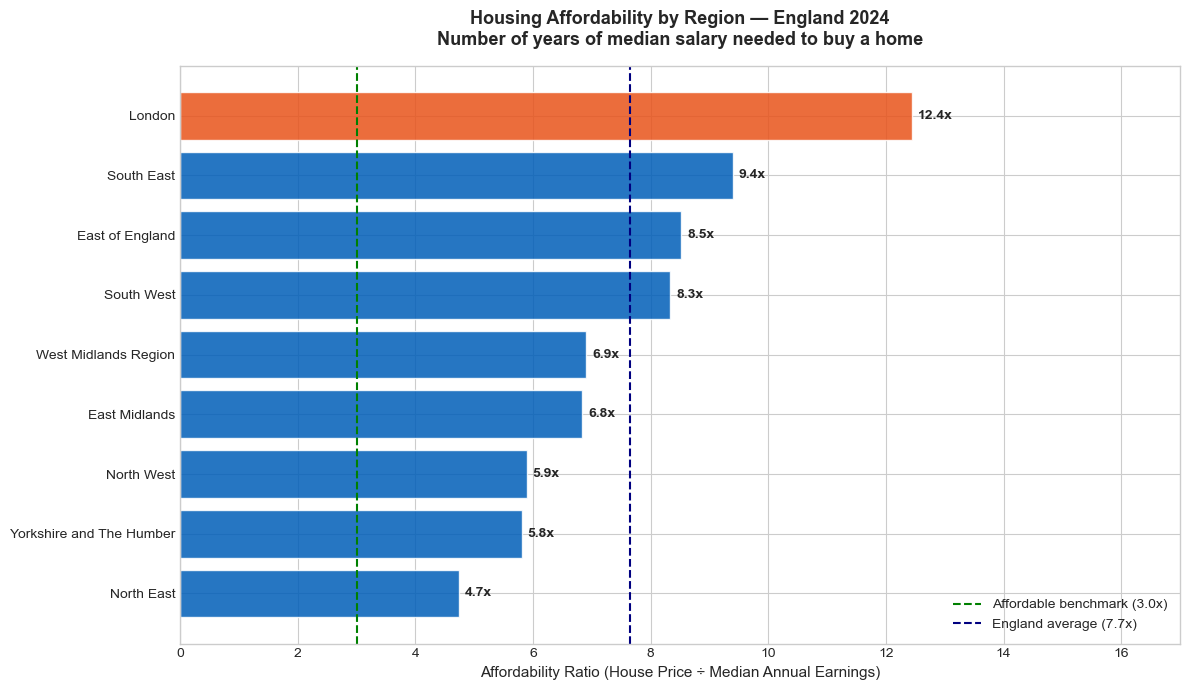

Chart 1 saved.

Most affordable: North East at 4.74x
Least affordable: London at 12.45x
England average: 7.65x


In [2]:
# ── CHART 1: Affordability Ratio by Region in 2024 ────────────────────────

df_2024 = df[df['year'] == 2024].sort_values('affordability_ratio')

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#E8531A' if r == 'London' else '#005EB8' 
          for r in df_2024['region']]

bars = ax.barh(df_2024['region'], df_2024['affordability_ratio'],
               color=colors, alpha=0.85, edgecolor='white')

# Value labels
for bar, val in zip(bars, df_2024['affordability_ratio']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}x', va='center', fontsize=10, fontweight='bold')

# Affordable benchmark line
ax.axvline(x=3.0, color='green', linestyle='--', linewidth=1.5,
           label='Affordable benchmark (3.0x)')

# England average line
england_avg = df_2024['affordability_ratio'].mean()
ax.axvline(x=england_avg, color='navy', linestyle='--', linewidth=1.5,
           label=f'England average ({england_avg:.1f}x)')

ax.set_title('Housing Affordability by Region — England 2024\n'
             'Number of years of median salary needed to buy a home',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Affordability Ratio (House Price ÷ Median Annual Earnings)',
              fontsize=11)
ax.set_xlim(0, 17)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/01_affordability_by_region_2024.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart 1 saved.")
print(f"\nMost affordable: {df_2024.iloc[0]['region']} at {df_2024.iloc[0]['affordability_ratio']}x")
print(f"Least affordable: {df_2024.iloc[-1]['region']} at {df_2024.iloc[-1]['affordability_ratio']}x")
print(f"England average: {england_avg:.2f}x")

### Finding 1 — No Region in England Meets the Affordable Benchmark

In 2024, not a single region in England meets the internationally 
recognised affordability benchmark of 3.0x median annual salary.

**Key observations:**
- London is the least affordable at **12.4x** — a worker on median 
  London earnings would need 12.4 years of their entire salary to 
  buy an average home
- The North East is the most affordable at **4.7x** — still 57% 
  above the affordable benchmark
- The England average is **7.7x** — more than double what is 
  considered affordable
- There is a clear North-South divide — the four least affordable 
  regions are all in the South (London, South East, East of England, 
  South West)
- Even the most affordable region (North East) requires nearly 5 
  years of full salary — with no spending on anything else

**Business implication:**
Housing affordability is not a London problem — it is an England-wide 
crisis. Even in the most affordable regions, a typical worker cannot 
buy a home without either a substantial inheritance, a very high 
deposit, or borrowing well beyond what most lenders consider prudent.

**Next:** How did we get here? Look at how affordability has changed 
over the past 10 years.

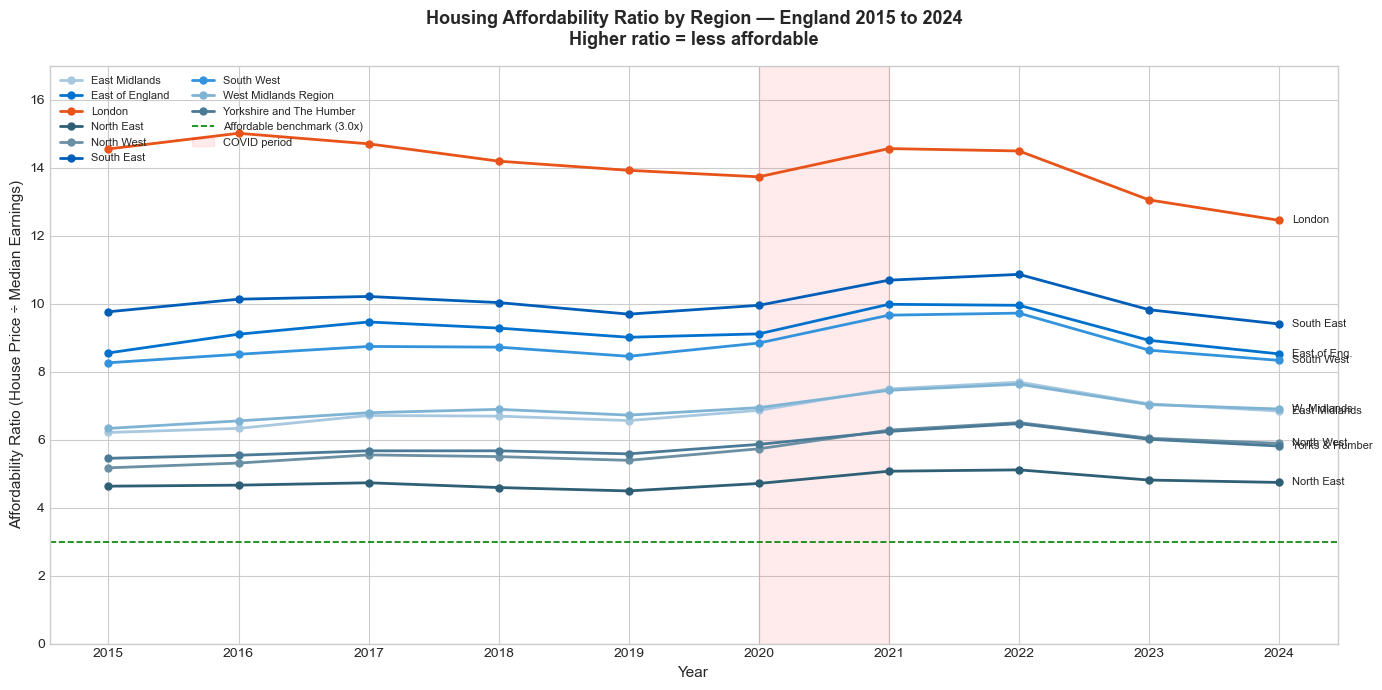

Change in affordability ratio 2015 to 2024:
  East Midlands                  6.21 → 6.84  (+10.1%)
  East of England                8.55 → 8.52  (-0.4%)
  London                         14.55 → 12.45  (-14.4%)
  North East                     4.63 → 4.74  (+2.4%)
  North West                     5.17 → 5.89  (+13.9%)
  South East                     9.76 → 9.40  (-3.7%)
  South West                     8.26 → 8.33  (+0.8%)
  West Midlands Region           6.33 → 6.90  (+9.0%)
  Yorkshire and The Humber       5.45 → 5.81  (+6.6%)


In [3]:
# ── CHART 2: Affordability Trend Over Time by Region ─────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

colors_map = {
    'London':                     '#E8531A',
    'South East':                 '#005EB8',
    'East of England':            '#0072CE',
    'South West':                 '#3393DD',
    'West Midlands Region':       '#7FB3D3',
    'East Midlands':              '#A8C8E0',
    'North West':                 '#6B8FA3',
    'Yorkshire and The Humber':   '#4A7A96',
    'North East':                 '#2E5F75',
}

for region, group in df.groupby('region'):
    group = group.sort_values('year')
    ax.plot(group['year'], group['affordability_ratio'],
            marker='o', markersize=5, linewidth=2,
            label=region, color=colors_map.get(region, 'gray'))
    # Label at end of line
    last = group.iloc[-1]
    ax.text(last['year'] + 0.1, last['affordability_ratio'],
            f"{region.replace('Yorkshire and The Humber', 'Yorks & Humber').replace('West Midlands Region', 'W. Midlands').replace('East of England', 'East of Eng.')}",
            fontsize=8, va='center')

# Affordable benchmark
ax.axhline(y=3.0, color='green', linestyle='--',
           linewidth=1.2, label='Affordable benchmark (3.0x)')

# COVID shading
ax.axvspan(2020, 2021, alpha=0.08, color='red', label='COVID period')

ax.set_title('Housing Affordability Ratio by Region — England 2015 to 2024\n'
             'Higher ratio = less affordable',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Affordability Ratio (House Price ÷ Median Earnings)',
              fontsize=11)
ax.set_xticks(range(2015, 2025))
ax.set_ylim(0, 17)
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('../outputs/charts/02_affordability_trend_over_time.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print key stats
print("Change in affordability ratio 2015 to 2024:")
for region in sorted(df['region'].unique()):
    r2015 = df[(df['region']==region) & (df['year']==2015)]['affordability_ratio'].values[0]
    r2024 = df[(df['region']==region) & (df['year']==2024)]['affordability_ratio'].values[0]
    change = r2024 - r2015
    pct = ((r2024 - r2015) / r2015) * 100
    print(f"  {region:<30} {r2015:.2f} → {r2024:.2f}  ({pct:+.1f}%)")

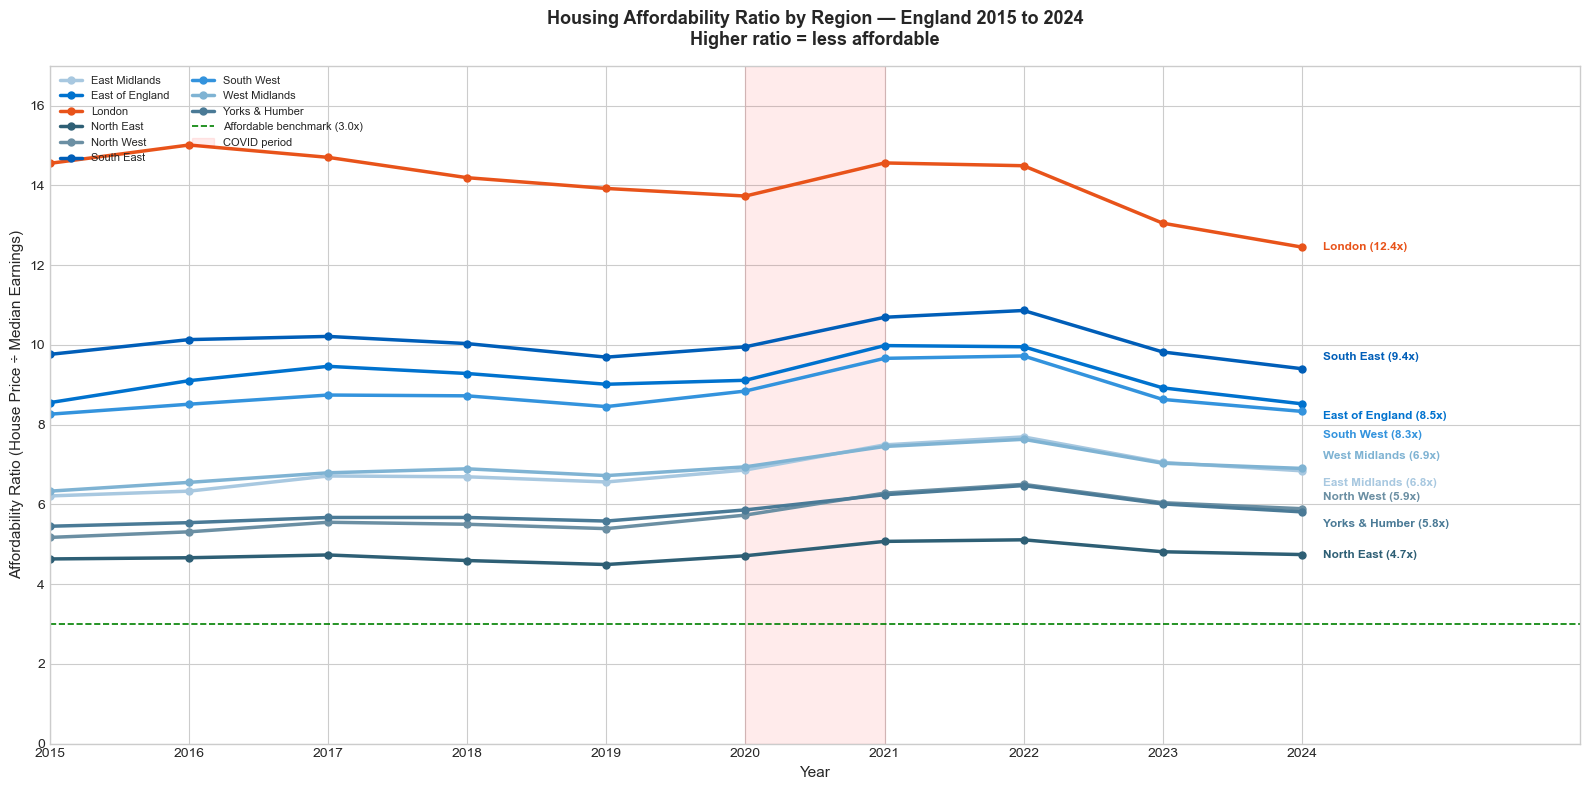

Chart 2 saved.


In [4]:
# ── CHART 2 IMPROVED: Better label spacing ────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 8))

colors_map = {
    'London':                     '#E8531A',
    'South East':                 '#005EB8',
    'East of England':            '#0072CE',
    'South West':                 '#3393DD',
    'West Midlands Region':       '#7FB3D3',
    'East Midlands':              '#A8C8E0',
    'North West':                 '#6B8FA3',
    'Yorkshire and The Humber':   '#4A7A96',
    'North East':                 '#2E5F75',
}

short_names = {
    'London':                     'London',
    'South East':                 'South East',
    'East of England':            'East of England',
    'South West':                 'South West',
    'West Midlands Region':       'West Midlands',
    'East Midlands':              'East Midlands',
    'North West':                 'North West',
    'Yorkshire and The Humber':   'Yorks & Humber',
    'North East':                 'North East',
}

# Manual vertical offsets to separate overlapping labels
label_offsets = {
    'London':                      0.0,
    'South East':                  0.3,
    'East of England':            -0.3,
    'South West':                 -0.6,
    'West Midlands Region':        0.3,
    'East Midlands':              -0.3,
    'North West':                  0.3,
    'Yorkshire and The Humber':   -0.3,
    'North East':                  0.0,
}

for region, group in df.groupby('region'):
    group = group.sort_values('year')
    ax.plot(group['year'], group['affordability_ratio'],
            marker='o', markersize=5, linewidth=2.5,
            label=short_names[region],
            color=colors_map.get(region, 'gray'))
    last = group.iloc[-1]
    offset = label_offsets.get(region, 0)
    ax.annotate(
        f"{short_names[region]} ({last['affordability_ratio']:.1f}x)",
        xy=(last['year'], last['affordability_ratio']),
        xytext=(last['year'] + 0.15, last['affordability_ratio'] + offset),
        fontsize=8.5, va='center',
        color=colors_map.get(region, 'gray'),
        fontweight='bold'
    )

# Affordable benchmark
ax.axhline(y=3.0, color='green', linestyle='--',
           linewidth=1.2, label='Affordable benchmark (3.0x)')

# COVID shading
ax.axvspan(2020, 2021, alpha=0.08, color='red', label='COVID period')

ax.set_title('Housing Affordability Ratio by Region — England 2015 to 2024\n'
             'Higher ratio = less affordable',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Affordability Ratio (House Price ÷ Median Earnings)',
              fontsize=11)
ax.set_xticks(range(2015, 2025))
ax.set_xlim(2015, 2026)
ax.set_ylim(0, 17)
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('../outputs/charts/02_affordability_trend_over_time.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

### Finding 2 — Affordability Has Worsened Since 2015 for Most Regions

The 10-year trend reveals that housing affordability has deteriorated 
across most of England, with the COVID period creating a sharp 
temporary spike that has only partially corrected.

**Key observations:**
- **North West (+13.9%)** and **East Midlands (+10.1%)** saw the 
  largest worsening in affordability over the decade
- **London (-14.4%)** is the only region that became significantly 
  more affordable — falling from 14.6x in 2015 to 12.4x in 2024. 
  This reflects London house price growth slowing while wages rose
- **COVID spike (2021)** — most regions saw a sharp jump in 2021 
  as house prices surged due to the stamp duty holiday while earnings 
  data reflected furloughed workers. This is a known data distortion
- **2022-2024 improvement** — rising interest rates cooled house 
  prices across most regions, improving ratios slightly from their 
  2022 peak. However this improvement has been modest
- The affordable benchmark of 3.0x has never been close to being 
  met in any region across the entire 10-year period

**Business implication:**
The directional trend is clear — England is getting less affordable 
over time despite short-term corrections. Without significant 
intervention in housing supply or earnings growth, the trajectory 
points toward continued deterioration.

**Next:** Which regions have changed most dramatically and which 
have been most resistant to change?

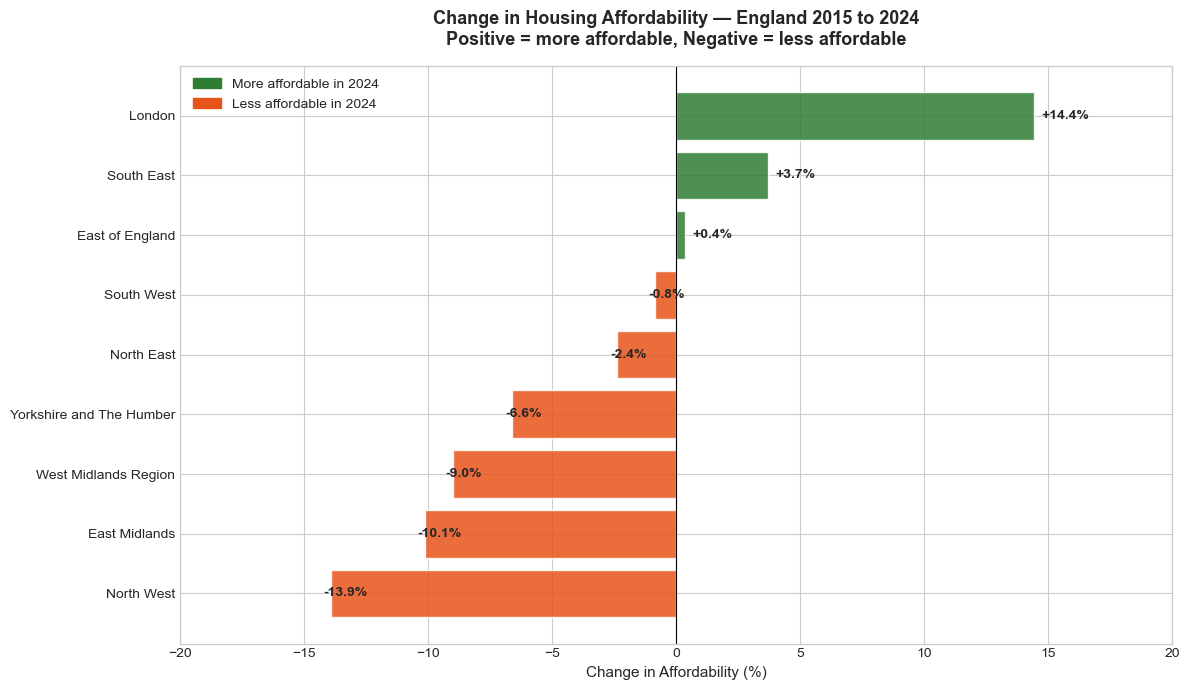

Chart 3 updated and saved.


In [7]:
# ── CHART 3 UPDATED: Flipped so positive = more affordable ───────────────

changes_df['pct_change_flipped'] = changes_df['pct_change'] * -1
changes_df_sorted = changes_df.sort_values('pct_change_flipped')

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#2E7D32' if x > 0 else '#E8531A' 
          for x in changes_df_sorted['pct_change_flipped']]

bars = ax.barh(changes_df_sorted['region'], 
               changes_df_sorted['pct_change_flipped'],
               color=colors, alpha=0.85, edgecolor='white')

# Value labels
for bar, val in zip(bars, changes_df_sorted['pct_change_flipped']):
    xpos = bar.get_width() + 0.3 if val >= 0 else bar.get_width() - 0.3
    align = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=0.8)

ax.set_title('Change in Housing Affordability — England 2015 to 2024\n'
             'Positive = more affordable, Negative = less affordable',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Change in Affordability (%)', fontsize=11)
ax.set_xlim(-20, 20)

from matplotlib.patches import Patch
legend = [Patch(color='#2E7D32', label='More affordable in 2024'),
          Patch(color='#E8531A', label='Less affordable in 2024')]
ax.legend(handles=legend, fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/03_affordability_change_2015_2024.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 updated and saved.")

### Finding 3 — The North is Getting Worse While London Improves

The decade-long change in affordability reveals a surprising pattern 
that runs counter to the popular narrative about the housing crisis.

**Key observations:**
- **London (+14.4%)** is the only region that became significantly 
  more affordable over the decade — London house price growth slowed 
  after 2017 while wages continued rising, improving the ratio. 
  London is still by far the least affordable region in England 
  but it is moving in the right direction
- **South East (+3.7%)** and **East of England (+0.4%)** also 
  improved slightly — Southern price growth slowed while earnings grew
- **North West (-13.9%)** is the fastest deteriorating region — 
  house prices have grown faster than wages here over the decade, 
  making it harder for local workers to buy
- **East Midlands (-10.1%)** and **West Midlands (-9.0%)** follow 
  closely — the Midlands engine of growth is pricing out its own workers
- The regions where affordability is worsening fastest are not the 
  most expensive — they are the mid-priced Northern and Midlands 
  regions where first-time buyers thought they could still afford to buy

**Business implication:**
The housing crisis is spreading outward from London. As buyers are 
priced out of the South they move North, driving up prices in regions 
where wages have not kept pace. This migration effect is measurable 
in the data and has significant implications for regional housing 
policy. The government's focus on building in London may be missing 
where the problem is now growing fastest.

**Next:** Build the machine learning model to predict where 
affordability is heading by 2028.